## 1. Setup & Dependencies

In [ ]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score,
                             recall_score, matthews_corrcoef, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Bidirectional, Dense,
                                     Dropout, BatchNormalization, Conv1D,
                                     MaxPooling1D, Multiply, Activation,
                                     Permute, RepeatVector, Flatten, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

import warnings; warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(f"GPU available: {gpus}")
if gpus:
    print(f"  -> Will use cuDNN LSTM kernel (fast path).")
else:
    print(f"  -> NO GPU detected. Switch runtime to T4 GPU before training.")

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
# --- Global plot styling: Times New Roman + light (thin) weight on every graph ---
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif", "serif"],
    "font.weight": "light",
    "axes.titleweight": "light",
    "axes.labelweight": "light",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.size": 11,
})

print("\n[OK] Dependencies loaded.")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  -> Will use cuDNN LSTM kernel (fast path).

[OK] Dependencies loaded.


## 2. Dataset Path


In [ ]:
# === Where is your SisFall data on Drive? ===
ZIP_ON_DRIVE    = "/content/drive/MyDrive/SisFall_dataset.zip"
FOLDER_ON_DRIVE = "/content/drive/MyDrive/SisFall_dataset"
LOCAL_DIR       = "/content/SisFall_dataset"

import os, shutil, zipfile, time

def _has_subjects(p):
    if not os.path.isdir(p):
        return False
    subs = [d for d in os.listdir(p)
            if os.path.isdir(os.path.join(p, d))
            and (d.startswith("SA") or d.startswith("SE"))]
    return len(subs) >= 5

def _mount_drive(force=False):
    try:
        from google.colab import drive
        if force or not os.path.exists("/content/drive/MyDrive"):
            drive.mount("/content/drive", force_remount=force)
    except ImportError:
        pass  # not running in Colab

# First mount (if needed)
_mount_drive(force=False)

# If neither expected Drive path exists, the mount may be stale (file uploaded
# AFTER mount). Force remount once to refresh.
if (not _has_subjects(LOCAL_DIR)
        and not os.path.isfile(ZIP_ON_DRIVE)
        and not _has_subjects(FOLDER_ON_DRIVE)):
    print("[..] Stale Drive mount? Forcing remount to refresh...")
    _mount_drive(force=True)

# Resolve the dataset
if _has_subjects(LOCAL_DIR):
    SISFALL_DIR = LOCAL_DIR
    print(f"[OK] Using existing local copy: {SISFALL_DIR}")
elif os.path.isfile(ZIP_ON_DRIVE):
    print(f"[..] Unzipping {ZIP_ON_DRIVE} -> {LOCAL_DIR} (one-off, ~1 min)")
    t0 = time.time()
    with zipfile.ZipFile(ZIP_ON_DRIVE) as z:
        z.extractall("/content")
    if not _has_subjects(LOCAL_DIR):
        for root, dirs, _ in os.walk("/content"):
            if _has_subjects(root):
                LOCAL_DIR = root
                break
    SISFALL_DIR = LOCAL_DIR
    print(f"[OK] Unzipped in {time.time()-t0:.1f}s -> {SISFALL_DIR}")
elif _has_subjects(FOLDER_ON_DRIVE):
    SISFALL_DIR = FOLDER_ON_DRIVE
    print(f"[!]  Reading directly from Drive (slow): {SISFALL_DIR}")
    print("     Tip: zip the folder and set ZIP_ON_DRIVE for ~10x speedup.")
else:
    raise FileNotFoundError(
        f"Could not find SisFall data after force-remount.\n"
        f"  Tried zip:    {ZIP_ON_DRIVE}\n"
        f"  Tried folder: {FOLDER_ON_DRIVE}\n"
        f"  Tried local:  {LOCAL_DIR}\n"
        f"Edit ZIP_ON_DRIVE / FOLDER_ON_DRIVE above to match your Drive layout."
    )

assert os.path.isdir(SISFALL_DIR), f"Not found: {SISFALL_DIR}"
subjects = sorted([d for d in os.listdir(SISFALL_DIR)
                    if os.path.isdir(os.path.join(SISFALL_DIR, d))
                    and (d.startswith("SA") or d.startswith("SE"))])
print(f"     Subjects found:    {len(subjects)}")
print(f"     Young adults (SA): {len([s for s in subjects if s.startswith('SA')])}")
print(f"     Elderly (SE):      {len([s for s in subjects if s.startswith('SE')])}")
print(f"     First few: {subjects[:5]}")


[OK] Using existing local copy: /content/SisFall_dataset
     Subjects found:    38
     Young adults (SA): 23
     Elderly (SE):      15
     First few: ['SA01', 'SA02', 'SA03', 'SA04', 'SA05']


## 3. Configuration

In [ ]:
# Signal processing
SAMPLING_RATE = 200
FILTER_ORDER = 4
FILTER_CUTOFF = 20      # Hz low-pass
WINDOW_SIZE = 400       # 2 seconds @ 200Hz
WINDOW_OVERLAP = 0.5

# === Input feature toggle ============================================
# SMV is used to LOCATE fall events for labelling (always on for that).
# But also feeding SMV in as an input channel gives the model a direct
# shortcut to the labelling rule. Set False for an honest leakage-free
# evaluation.
USE_SMV_CHANNEL = False   # was True in earlier runs; recommend False
N_CHANNELS = 10 if USE_SMV_CHANNEL else 9

# Fall localisation: keep windows containing the SMV impact peak (raw, in g).
FALL_PEAK_GUARD = 100   # samples (0.5s) of slack around the peak

# Training
EPOCHS = 60
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
PATIENCE_ES = 12
PATIENCE_LR = 5
L2_REG = 5e-4
SEEDS = [42]

OUTPUT_DIR = "results"
import os; os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Window:   {WINDOW_SIZE} samples ({WINDOW_SIZE/SAMPLING_RATE:.2f}s)")
print(f"Channels: {N_CHANNELS}  (SMV input channel: {'ON' if USE_SMV_CHANNEL else 'OFF'})")
print(f"Filter:   Butterworth order {FILTER_ORDER}, LP {FILTER_CUTOFF} Hz")
print(f"Training: {EPOCHS} epochs, batch {BATCH_SIZE}, lr {LEARNING_RATE}, L2 {L2_REG}")
print(f"Fall labelling uses SMV peaks regardless (only changes input features).")

Window:   400 samples (2.00s)
Channels: 9  (SMV input channel: OFF)
Filter:   Butterworth order 4, LP 20 Hz
Training: 60 epochs, batch 64, lr 0.001, L2 0.0005
Fall labelling uses SMV peaks regardless (only changes input features).


## 4. Data Loading

In [ ]:
def load_sisfall(data_dir):
    """Load all SisFall recordings, convert to physical units."""
    recordings, labels, subject_ids = [], [], []
    skipped = 0
    for subject_dir in sorted(os.listdir(data_dir)):
        subj_path = os.path.join(data_dir, subject_dir)
        if not os.path.isdir(subj_path): continue
        if not (subject_dir.startswith("SA") or subject_dir.startswith("SE")):
            continue
        for fname in sorted(os.listdir(subj_path)):
            if not fname.endswith('.txt'): continue
            fpath = os.path.join(subj_path, fname)
            try:
                with open(fpath, 'r') as f:
                    lines = f.readlines()
                rows = []
                for line in lines:
                    line = line.strip().rstrip(',;')
                    if not line: continue
                    parts = line.split(',')
                    if len(parts) >= 9:
                        try:
                            rows.append([float(p.strip()) for p in parts[:9]])
                        except ValueError:
                            continue
                if len(rows) < WINDOW_SIZE:
                    skipped += 1; continue
                data = np.array(rows, dtype=np.float32)
                # Convert to physical units
                data[:, 0:3] = (data[:, 0:3] * 16.0) / 8192.0     # ADXL345 (g)
                data[:, 3:6] = (data[:, 3:6] * 2000.0) / 65536.0  # ITG3200 (deg/s)
                data[:, 6:9] = (data[:, 6:9] * 8.0) / 16384.0     # MMA8451Q (g)
                is_fall = 1 if fname.startswith('F') else 0
                recordings.append(data); labels.append(is_fall)
                subject_ids.append(subject_dir)
            except Exception:
                skipped += 1; continue
    labels = np.array(labels)
    print(f"{len(recordings)} recordings loaded (skipped {skipped})")
    print(f"Falls: {int(labels.sum())} | ADLs: {int((labels==0).sum())}")
    print(f"Subjects: {len(set(subject_ids))} "
          f"(SA={len([s for s in set(subject_ids) if s.startswith('SA')])}, "
          f"SE={len([s for s in set(subject_ids) if s.startswith('SE')])})")
    return recordings, labels, subject_ids

recordings, labels, subject_ids = load_sisfall(SISFALL_DIR)


[OK] 4505 recordings loaded (skipped 0)
     Falls: 1798 | ADLs: 2707
     Subjects: 38 (SA=23, SE=15)


## 5. Exploratory Data Analysis

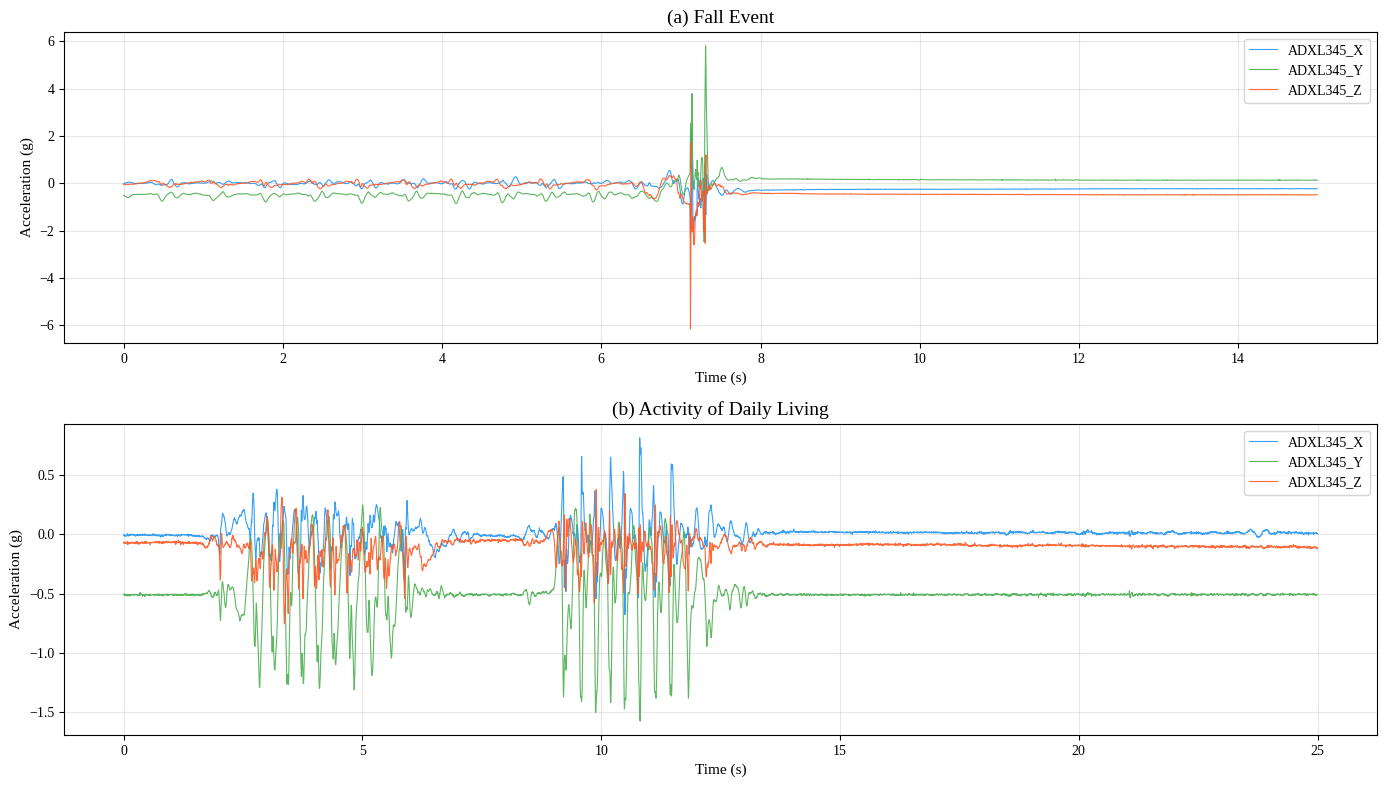

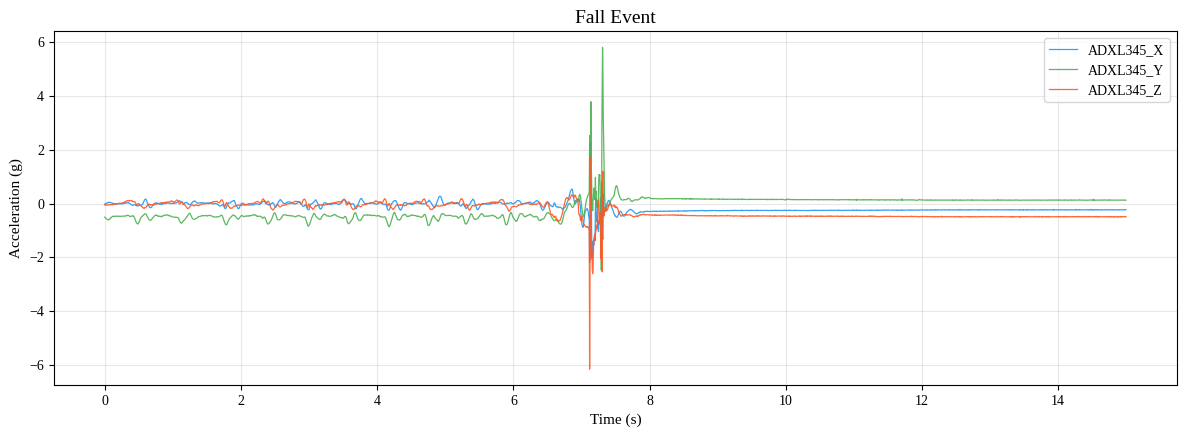

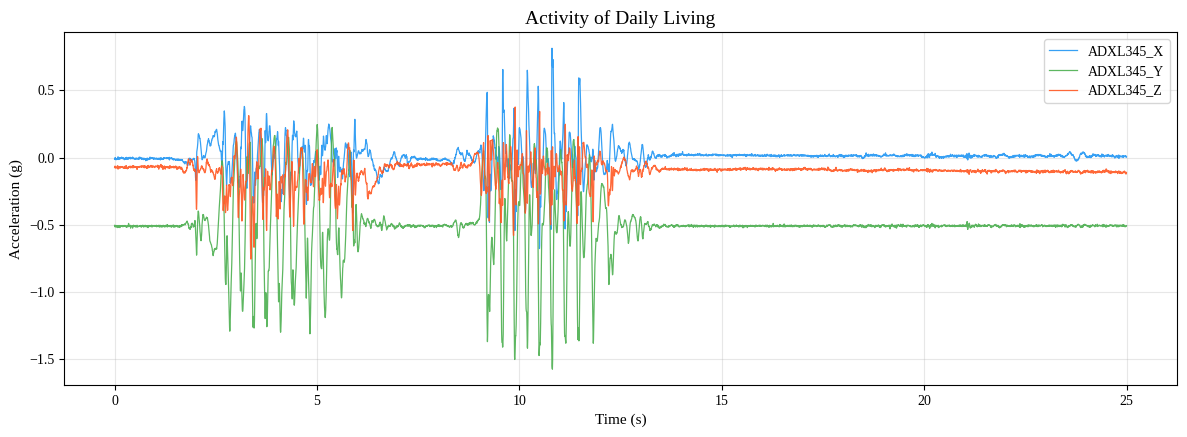

Saved fig1_fall_vs_adl.png + fig1a_fall_event.png + fig1b_adl.png


In [ ]:
channel_names = ['ADXL345_X','ADXL345_Y','ADXL345_Z',
                 'ITG3200_X','ITG3200_Y','ITG3200_Z',
                 'MMA8451Q_X','MMA8451Q_Y','MMA8451Q_Z'] + (['SMV'] if USE_SMV_CHANNEL else [])
fall_indices = np.where(labels == 1)[0]
adl_indices = np.where(labels == 0)[0]
fall_data = recordings[fall_indices[0]]
adl_data = recordings[adl_indices[10]]
colors = ['#2196F3','#4CAF50','#FF5722']

# ---- Combined panel (a)+(b) ----
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
t = np.arange(len(fall_data)) / SAMPLING_RATE
for i in range(3):
    axes[0].plot(t, fall_data[:, i], color=colors[i],
                 label=channel_names[i], linewidth=0.8, alpha=0.9)
axes[0].set_title('(a) Fall Event', fontsize=14)
axes[0].set_ylabel('Acceleration (g)'); axes[0].set_xlabel('Time (s)')
axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)
t = np.arange(len(adl_data)) / SAMPLING_RATE
for i in range(3):
    axes[1].plot(t, adl_data[:, i], color=colors[i],
                 label=channel_names[i], linewidth=0.8, alpha=0.9)
axes[1].set_title('(b) Activity of Daily Living', fontsize=14)
axes[1].set_ylabel('Acceleration (g)'); axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_fall_vs_adl.png'), dpi=200, bbox_inches='tight')
plt.show()

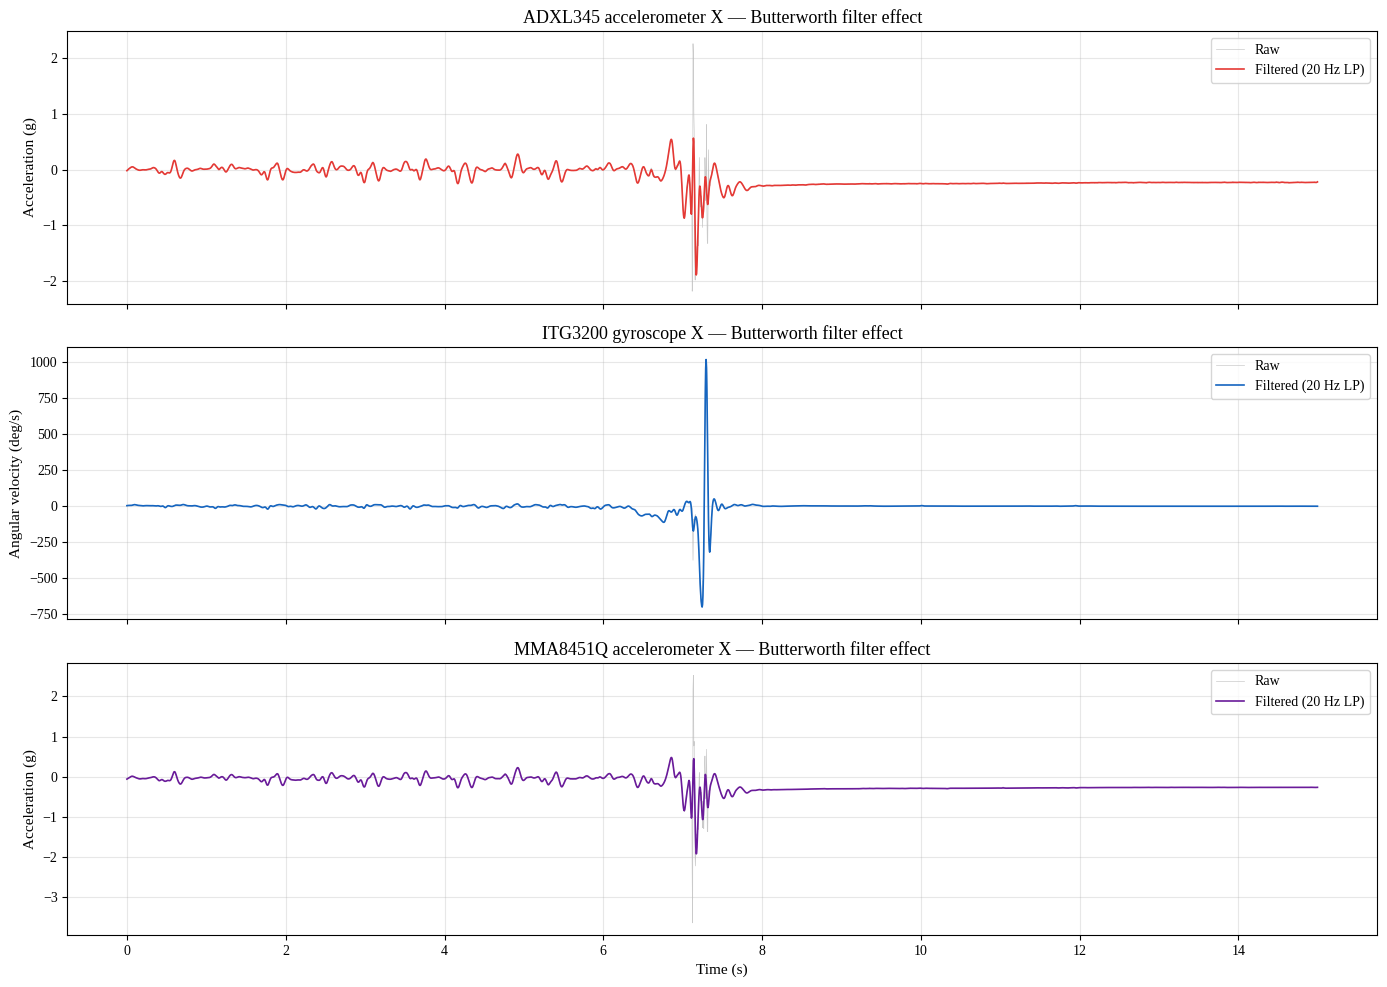

In [ ]:
def butterworth_filter(data, cutoff=FILTER_CUTOFF, fs=SAMPLING_RATE,
                        order=FILTER_ORDER):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff/nyq, btype='low')
    out = np.zeros_like(data)
    for ch in range(data.shape[1]):
        out[:, ch] = filtfilt(b, a, data[:, ch])
    return out

raw = fall_data; filtered = butterworth_filter(raw)
t = np.arange(len(raw)) / SAMPLING_RATE
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# (a) ADXL345 accelerometer X (channel 0)
axes[0].plot(t, raw[:, 0], color='#BDBDBD', linewidth=0.5, label='Raw', alpha=0.8)
axes[0].plot(t, filtered[:, 0], color='#E53935', linewidth=1.2,
             label='Filtered (20 Hz LP)')
axes[0].set_title('ADXL345 accelerometer X — Butterworth filter effect')
axes[0].set_ylabel('Acceleration (g)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) ITG3200 gyroscope X (channel 3)
axes[1].plot(t, raw[:, 3], color='#BDBDBD', linewidth=0.5, label='Raw', alpha=0.8)
axes[1].plot(t, filtered[:, 3], color='#1565C0', linewidth=1.2,
             label='Filtered (20 Hz LP)')
axes[1].set_title('ITG3200 gyroscope X — Butterworth filter effect')
axes[1].set_ylabel('Angular velocity (deg/s)'); axes[1].legend(); axes[1].grid(alpha=0.3)

# (c) MMA8451Q accelerometer X (channel 6)
axes[2].plot(t, raw[:, 6], color='#BDBDBD', linewidth=0.5, label='Raw', alpha=0.8)
axes[2].plot(t, filtered[:, 6], color='#6A1B9A', linewidth=1.2,
             label='Filtered (20 Hz LP)')
axes[2].set_title('MMA8451Q accelerometer X — Butterworth filter effect')
axes[2].set_ylabel('Acceleration (g)'); axes[2].set_xlabel('Time (s)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_butterworth.png'),
            dpi=200, bbox_inches='tight')
plt.show()


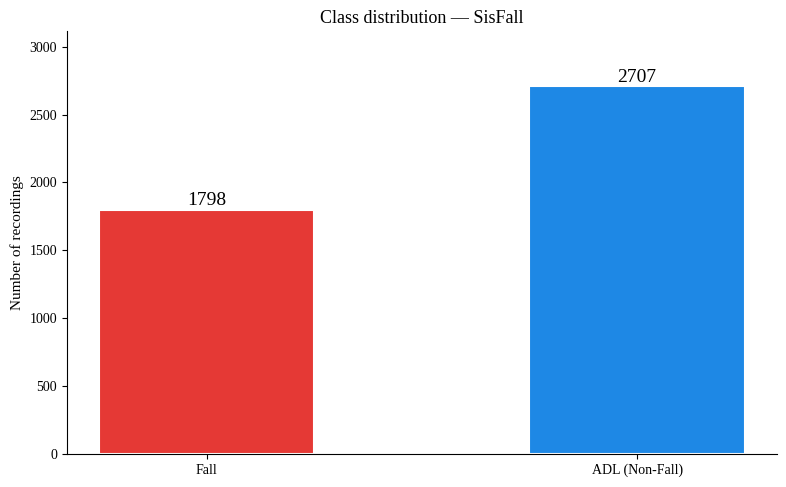

Falls: 1798, ADLs: 2707, Ratio 1:1.51


In [ ]:
n_falls = int(labels.sum()); n_adls = len(labels) - n_falls
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Fall','ADL (Non-Fall)'], [n_falls, n_adls],
              color=['#E53935','#1E88E5'], width=0.5,
              edgecolor='white', linewidth=1.5)
ax.set_ylabel('Number of recordings')
ax.set_title('Class distribution — SisFall')
for bar, val in zip(bars, [n_falls, n_adls]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val),
            ha='center', va='bottom', fontsize=14)
ax.set_ylim(0, max(n_falls, n_adls)*1.15); sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_class_distribution.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f"Falls: {n_falls}, ADLs: {n_adls}, Ratio 1:{n_adls/n_falls:.2f}")


## 6. Preprocessing

In [ ]:
def add_smv_channel(data):
    """Append Signal Magnitude Vector from accelerometer (ADXL345)."""
    smv = np.sqrt(np.sum(data[:, 0:3]**2, axis=1, keepdims=True))
    return np.concatenate([data, smv], axis=1).astype(np.float32)

def per_recording_zscore(data):
    """Z-score each channel within a recording (kills subject offsets)."""
    mean = data.mean(axis=0, keepdims=True)
    std  = data.std(axis=0, keepdims=True) + 1e-8
    return ((data - mean) / std).astype(np.float32)

def find_fall_peak(data):
    """Locate the fall impact: argmax of accelerometer SMV (raw, in g)."""
    smv = np.sqrt(np.sum(data[:, 0:3]**2, axis=1))
    return int(np.argmax(smv)), float(smv.max())

def preprocess_and_segment(recordings, labels, subject_ids):
    """
    Per-recording z-score (+ optional SMV channel), then sliding-window segment.
    For FALL recordings, only windows containing the SMV impact peak
    (+/- FALL_PEAK_GUARD samples) are labelled 1; all other windows are dropped.
    For ADL recordings, every window is labelled 0.
    """
    step = int(WINDOW_SIZE * (1 - WINDOW_OVERLAP))
    Xs, ys, subjs = [], [], []
    print("Filtering, normalising, locating fall events, windowing...")
    n_kept_fall = n_drop_pre_post = n_adl = 0
    fall_peak_vals = []

    for rec, lab, subj in zip(recordings, labels, subject_ids):
        f = butterworth_filter(rec)
        if USE_SMV_CHANNEL:
            f = add_smv_channel(f)
        f = per_recording_zscore(f)

        if lab == 1:
            peak_idx, peak_val = find_fall_peak(rec)
            fall_peak_vals.append(peak_val)
            for s in range(0, len(f) - WINDOW_SIZE + 1, step):
                if s - FALL_PEAK_GUARD <= peak_idx <= s + WINDOW_SIZE + FALL_PEAK_GUARD:
                    Xs.append(f[s:s+WINDOW_SIZE]); ys.append(1); subjs.append(subj)
                    n_kept_fall += 1
                else:
                    n_drop_pre_post += 1
        else:
            for s in range(0, len(f) - WINDOW_SIZE + 1, step):
                Xs.append(f[s:s+WINDOW_SIZE]); ys.append(0); subjs.append(subj)
                n_adl += 1

    X_all = np.array(Xs, dtype=np.float32)
    y_all = np.array(ys, dtype=np.int32)
    subj_all = np.array(subjs)

    print(f"  Fall windows kept (impact-containing): {n_kept_fall}")
    print(f"  Fall windows dropped (pre/post-fall):  {n_drop_pre_post}")
    print(f"  ADL windows:                           {n_adl}")
    print(f"  Imbalance fall:non-fall = 1:{n_adl/max(n_kept_fall,1):.1f}")
    print(f"  Fall SMV peaks: median={np.median(fall_peak_vals):.2f}g  "
          f"min={min(fall_peak_vals):.2f}g  max={max(fall_peak_vals):.2f}g")

    rng = np.random.default_rng(SEED)
    sa = sorted([s for s in set(subj_all) if s.startswith("SA")])
    se = sorted([s for s in set(subj_all) if s.startswith("SE")])
    rng.shuffle(sa); rng.shuffle(se)
    def sp(lst):
        n=len(lst); a=int(0.7*n); b=int(0.85*n)
        return set(lst[:a]), set(lst[a:b]), set(lst[b:])
    sa_tr,sa_va,sa_te = sp(sa); se_tr,se_va,se_te = sp(se)
    train_s = sa_tr|se_tr; val_s = sa_va|se_va; test_s = sa_te|se_te

    tr = np.array([s in train_s for s in subj_all])
    va = np.array([s in val_s   for s in subj_all])
    te = np.array([s in test_s  for s in subj_all])
    X_train, y_train = X_all[tr], y_all[tr]
    X_val,   y_val   = X_all[va], y_all[va]
    X_test,  y_test  = X_all[te], y_all[te]

    print(f"  Train: {len(X_train)} ({len(train_s)} subj) falls={int(y_train.sum())}")
    print(f"  Val:   {len(X_val)} ({len(val_s)} subj) falls={int(y_val.sum())}")
    print(f"  Test:  {len(X_test)} ({len(test_s)} subj) falls={int(y_test.sum())}")
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_and_segment(
    recordings, labels, subject_ids)

cw_arr = compute_class_weight("balanced", classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: cw_arr[0], 1: cw_arr[1]}
print(f"\nClass weights: non-fall={class_weight_dict[0]:.3f} fall={class_weight_dict[1]:.3f}")


Filtering, normalising, locating fall events, windowing...
  Fall windows kept (impact-containing): 5398
  Fall windows dropped (pre/post-fall):  19652
  ADL windows:                           49359
  Imbalance fall:non-fall = 1:9.1
  Fall SMV peaks: median=3.10g  min=0.85g  max=13.19g
  Train: 37995 (26 subj) falls=3822
  Val:   7146 (5 subj) falls=676
  Test:  9616 (7 subj) falls=900

Class weights: non-fall=0.556 fall=4.971


## 7. Model Architecture


In [ ]:
INPUT_SHAPE = (WINDOW_SIZE, N_CHANNELS)

def build_cnn_lstm():
    """Proposed CNN-LSTM: conv front end + stacked LSTM backbone."""
    inp = Input(shape=INPUT_SHAPE)
    x = Conv1D(32, 5, activation="relu", padding="same",
               kernel_regularizer=l2(L2_REG))(inp)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x)
    x = Conv1D(64, 3, activation="relu", padding="same",
               kernel_regularizer=l2(L2_REG))(x)
    x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.3)(x)
    x = LSTM(64, return_sequences=True, kernel_regularizer=l2(L2_REG))(x)
    x = BatchNormalization()(x); x = Dropout(0.4)(x)
    x = LSTM(64, kernel_regularizer=l2(L2_REG))(x)
    x = BatchNormalization()(x); x = Dropout(0.4)(x)
    x = Dense(32, activation="relu", kernel_regularizer=l2(L2_REG))(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out, name="CNN_LSTM")

print(f"CNN-LSTM (proposed): {build_cnn_lstm().count_params():,} parameters")

CNN-LSTM (proposed): 76,737 parameters


## 8. Training & Evaluation

In [ ]:
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Sensitivity': tp/(tp+fn)*100 if (tp+fn) else 0,
        'Specificity': tn/(tn+fp)*100 if (tn+fp) else 0,
        'Accuracy':    accuracy_score(y_true, y_pred)*100,
        'F1-Score':    f1_score(y_true, y_pred)*100,
        'MCC':         matthews_corrcoef(y_true, y_pred),
        'AUC':         roc_auc_score(y_true, y_prob),
        'TP':int(tp),'TN':int(tn),'FP':int(fp),'FN':int(fn)
    }

def train_one(name, builder, seed=SEED, verbose=2):
    tf.keras.utils.set_random_seed(seed)
    model = builder()
    model.compile(optimizer=Adam(LEARNING_RATE),
                   loss='binary_crossentropy', metrics=['accuracy'])
    cbs = [EarlyStopping(monitor='val_loss', patience=PATIENCE_ES,
                          restore_best_weights=True, verbose=0),
           ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=PATIENCE_LR, min_lr=1e-6, verbose=0)]
    print(f'\n=== {name} (seed={seed}, params={model.count_params():,}) ===')
    t0 = time.time()
    h = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH_SIZE,
                  class_weight=class_weight_dict, callbacks=cbs,
                  verbose=verbose)
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    m = compute_metrics(y_test, y_pred, y_prob)
    print(f'  trained {len(h.history["loss"])} ep in {(time.time()-t0)/60:.1f} min')
    print(f'  Sens={m["Sensitivity"]:.2f} Spec={m["Specificity"]:.2f} '
          f'Acc={m["Accuracy"]:.2f} F1={m["F1-Score"]:.2f} '
          f'MCC={m["MCC"]:.3f} AUC={m["AUC"]:.3f}')
    return model, m, h, y_pred, y_prob

In [ ]:
# 3) CNN-LSTM
model_3, metrics_3, history_3, ypred_3, yprob_3 = train_one(
    "CNN-LSTM (proposed)", build_cnn_lstm, seed=42)


=== CNN-LSTM (proposed) (seed=42, params=76,737) ===
Epoch 1/60
594/594 - 22s - 36ms/step - accuracy: 0.8349 - loss: 0.4790 - val_accuracy: 0.9114 - val_loss: 0.3580 - learning_rate: 0.0010
Epoch 2/60
594/594 - 12s - 20ms/step - accuracy: 0.9345 - loss: 0.3068 - val_accuracy: 0.9633 - val_loss: 0.2456 - learning_rate: 0.0010
Epoch 3/60
594/594 - 12s - 20ms/step - accuracy: 0.9416 - loss: 0.2727 - val_accuracy: 0.9545 - val_loss: 0.2458 - learning_rate: 0.0010
Epoch 4/60
594/594 - 12s - 20ms/step - accuracy: 0.9560 - loss: 0.2286 - val_accuracy: 0.9583 - val_loss: 0.2275 - learning_rate: 0.0010
Epoch 5/60
594/594 - 12s - 20ms/step - accuracy: 0.9612 - loss: 0.2060 - val_accuracy: 0.9622 - val_loss: 0.2201 - learning_rate: 0.0010
Epoch 6/60
594/594 - 21s - 35ms/step - accuracy: 0.9677 - loss: 0.1898 - val_accuracy: 0.9583 - val_loss: 0.2066 - learning_rate: 0.0010
Epoch 7/60
594/594 - 12s - 20ms/step - accuracy: 0.9689 - loss: 0.1759 - val_accuracy: 0.9762 - val_loss: 0.1490 - learning_

## 9. Results Visualisation

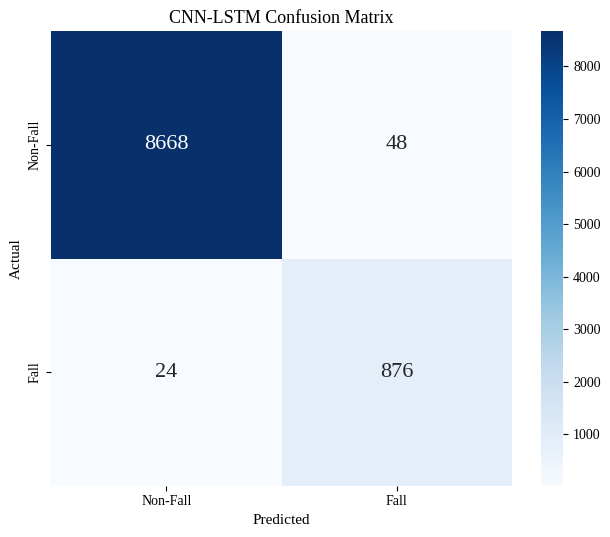

Saved fig6_confusion_matrices.png  (TN=8668, FP=48, FN=24, TP=876)


In [ ]:
# Confusion matrix for the proposed CNN-LSTM on the held-out test partition.
cm = confusion_matrix(y_test, ypred_3)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Non-Fall","Fall"], yticklabels=["Non-Fall","Fall"],
            annot_kws={"size": 16})
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("CNN-LSTM Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig6_confusion_matrices.png"), dpi=200, bbox_inches="tight")
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"Saved fig6_confusion_matrices.png  (TN={tn}, FP={fp}, FN={fn}, TP={tp})")

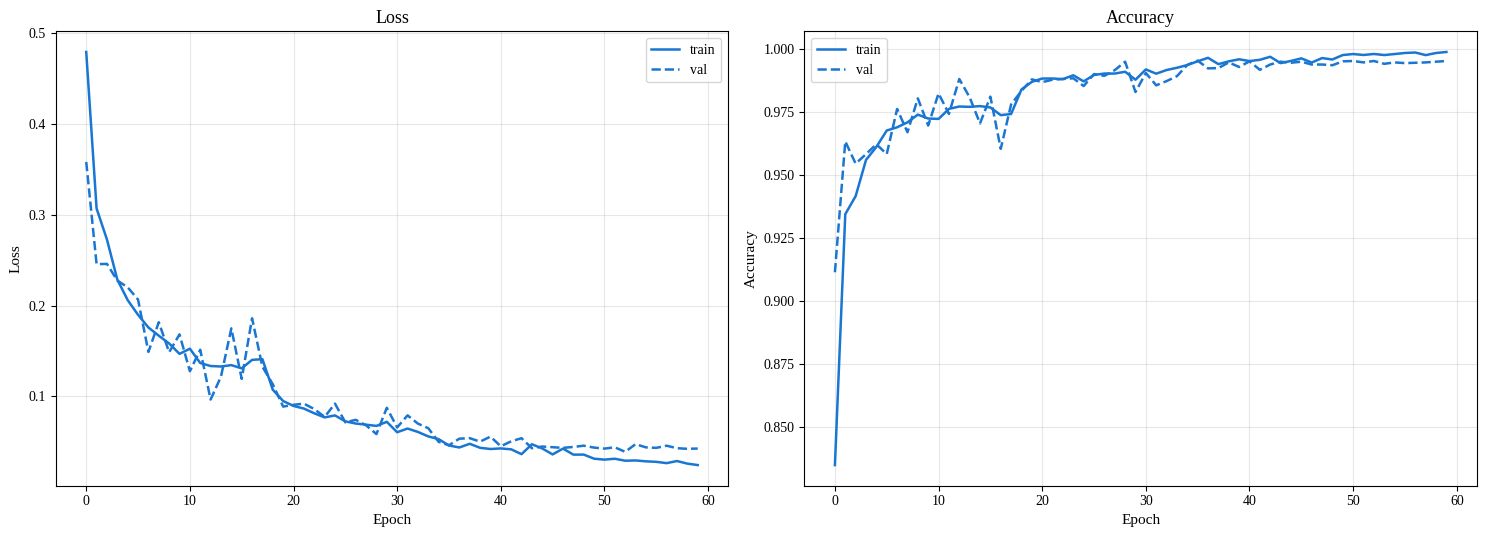

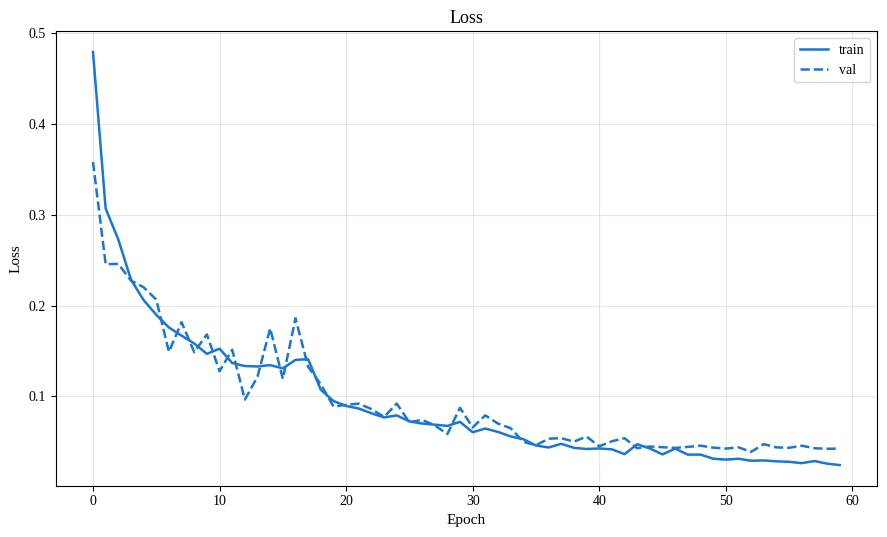

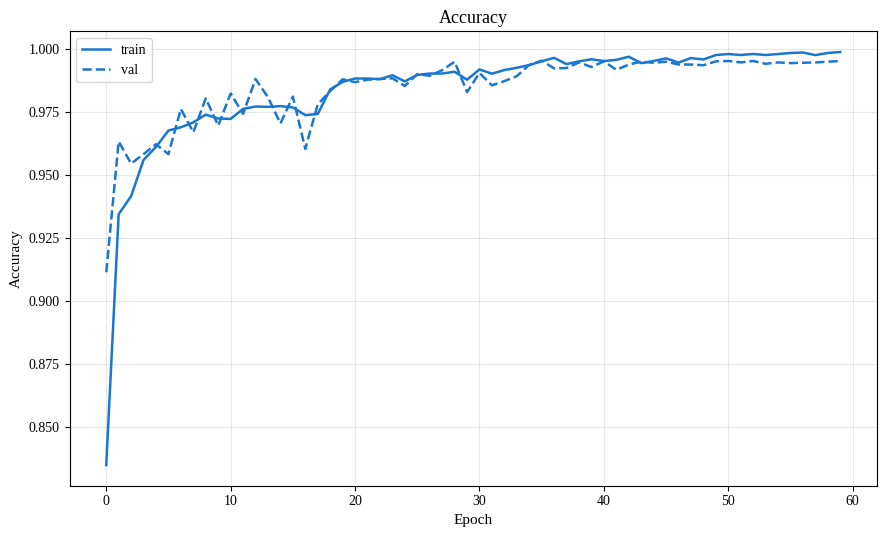

Saved fig7_training_curves.png + fig7a_loss.png + fig7b_accuracy.png


In [ ]:
# Training and validation curves for the proposed CNN-LSTM.
h = history_3
color_blue = "#1976D2"

# ---- Combined: Loss + Accuracy ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(h.history["loss"],     color=color_blue, lw=1.8, label="train")
axes[0].plot(h.history["val_loss"], color=color_blue, lw=1.8, ls="--", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(h.history["accuracy"],     color=color_blue, lw=1.8, label="train")
axes[1].plot(h.history["val_accuracy"], color=color_blue, lw=1.8, ls="--", label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig7_training_curves.png"), dpi=200, bbox_inches="tight")
plt.show()

## 10. Saliency Visualisation for the CNN-LSTM (Proposed)



Fall window predicted probability: 0.990
ADL  window predicted probability: 0.000


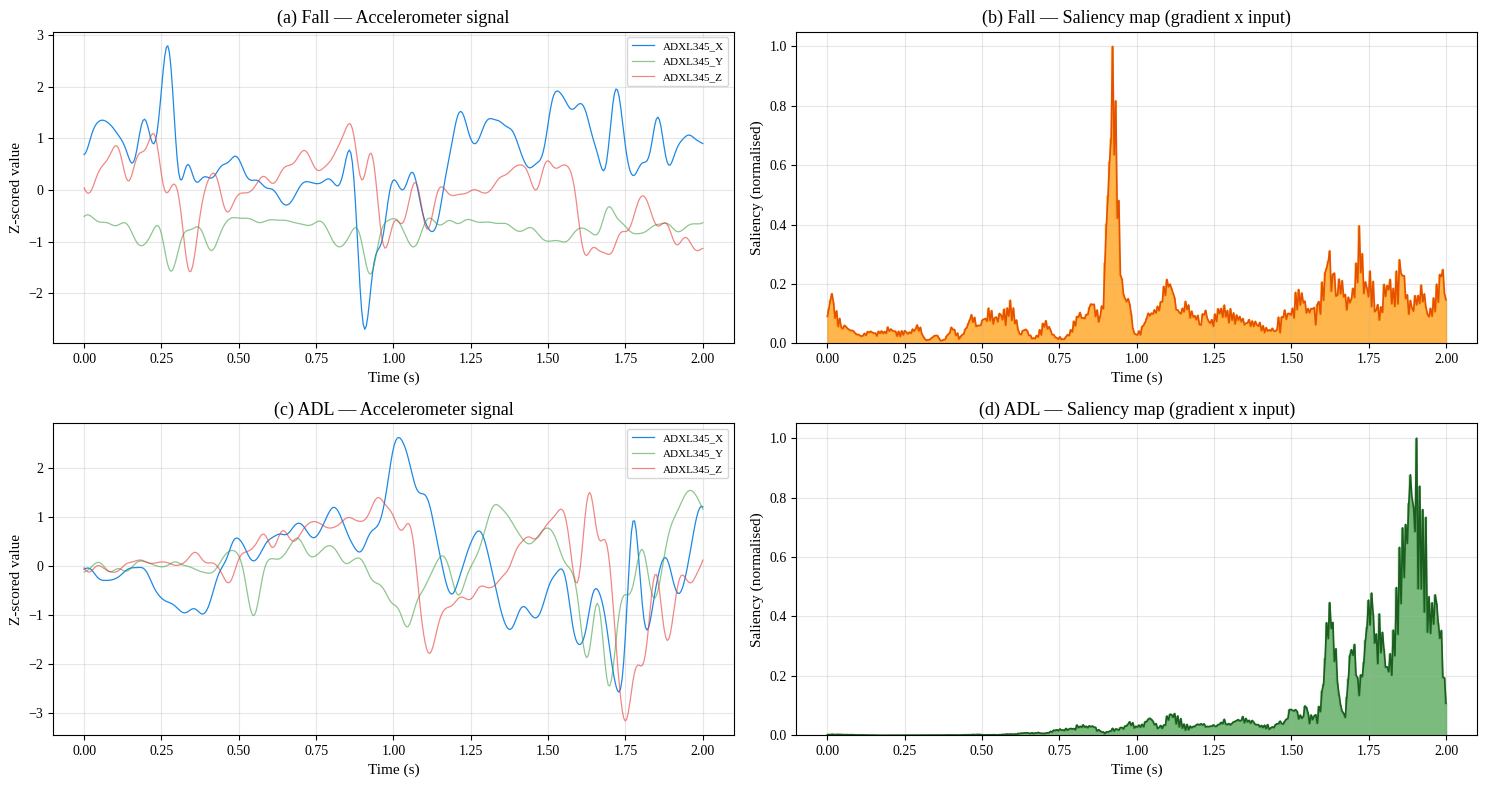

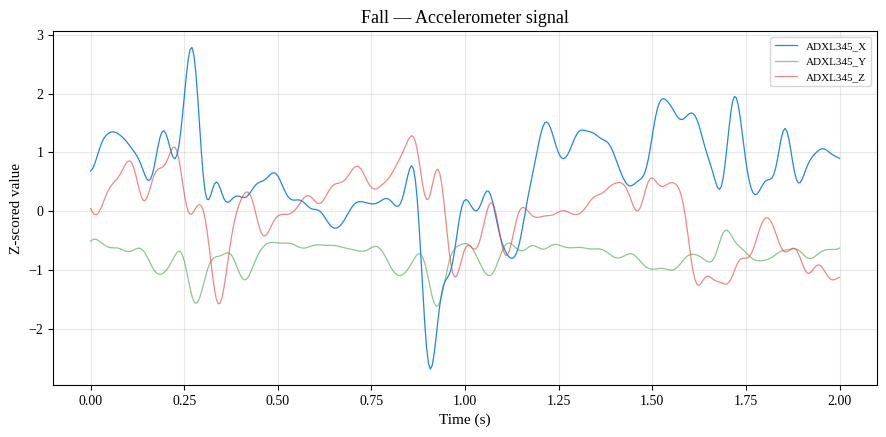

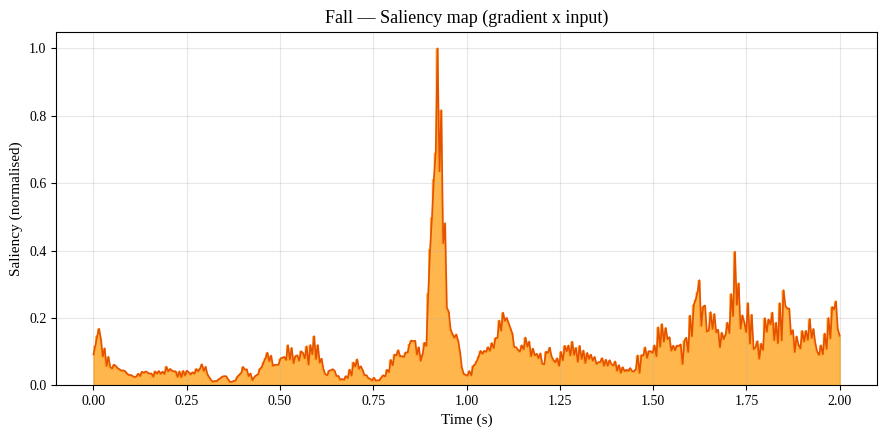

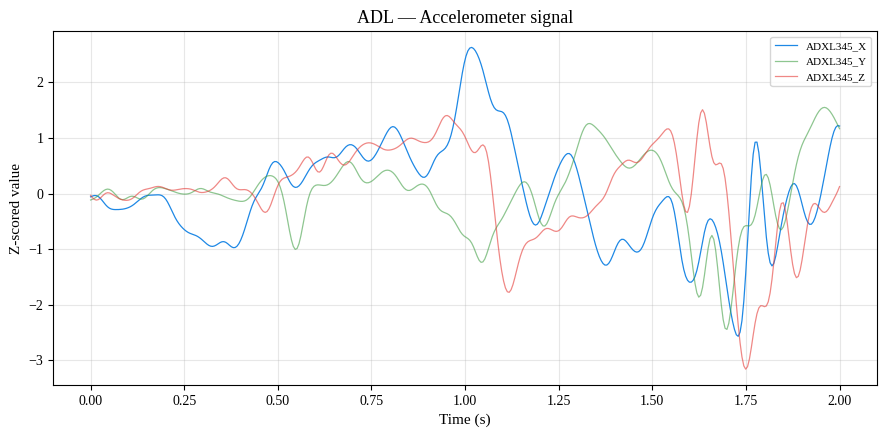

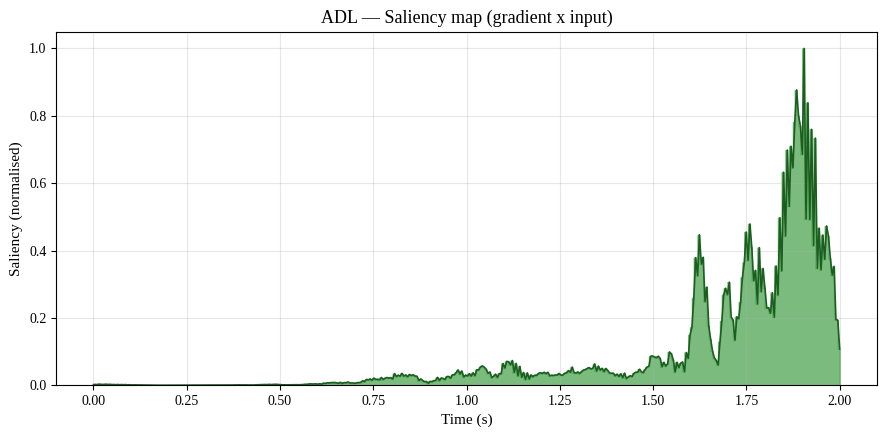

Saliency figures saved (combined + 4 separate panels).


In [ ]:
# Gradient × input saliency for the CNN-LSTM (proposed model)
import tensorflow as tf

def gradient_input_saliency(model, x):
    """Compute |grad(p_fall) · x| L2-normed across channels."""
    x_t = tf.convert_to_tensor(x[np.newaxis, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_t)
        p = model(x_t, training=False)[0, 0]
    grad = tape.gradient(p, x_t).numpy()[0]              # (T, C)
    sal = np.abs(grad * x)                               # (T, C)
    sal = np.linalg.norm(sal, axis=1)                    # (T,)
    if sal.max() > 0:
        sal = sal / sal.max()
    return sal, float(p.numpy())

# Find a correctly classified fall and ADL in the test set
fall_idx = np.where((y_test == 1) & (ypred_3 == 1))[0]   # model_3 = CNN-LSTM
adl_idx  = np.where((y_test == 0) & (ypred_3 == 0))[0]
assert len(fall_idx) > 0 and len(adl_idx) > 0, "no correctly classified examples found"

fall_x = X_test[fall_idx[0]]
adl_x  = X_test[adl_idx[0]]
fall_sal, fall_prob = gradient_input_saliency(model_3, fall_x)
adl_sal,  adl_prob  = gradient_input_saliency(model_3, adl_x)

print(f"Fall window predicted probability: {fall_prob:.3f}")
print(f"ADL  window predicted probability: {adl_prob:.3f}")

t_sig = np.linspace(0, WINDOW_SIZE / SAMPLING_RATE, WINDOW_SIZE)

def _plot_signal(ax, x, title):
    ax.plot(t_sig, x[:, 0], color="#1E88E5", lw=0.9, label="ADXL345_X")
    ax.plot(t_sig, x[:, 1], color="#43A047", lw=0.9, alpha=0.6, label="ADXL345_Y")
    ax.plot(t_sig, x[:, 2], color="#E53935", lw=0.9, alpha=0.6, label="ADXL345_Z")
    ax.set_title(title)
    ax.set_ylabel("Z-scored value"); ax.set_xlabel("Time (s)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

def _plot_saliency(ax, sal, title, fill, line):
    ax.fill_between(t_sig, sal, color=fill, alpha=0.7, step="pre")
    ax.plot(t_sig, sal, color=line, lw=1.2)
    ax.set_title(title)
    ax.set_ylabel("Saliency (normalised)"); ax.set_xlabel("Time (s)")
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

# ---- Combined 2x2 panel ----
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
_plot_signal(axes[0, 0], fall_x, "(a) Fall — Accelerometer signal")
_plot_saliency(axes[0, 1], fall_sal, "(b) Fall — Saliency map (gradient x input)", "#FF9800", "#E65100")
_plot_signal(axes[1, 0], adl_x, "(c) ADL — Accelerometer signal")
_plot_saliency(axes[1, 1], adl_sal, "(d) ADL — Saliency map (gradient x input)", "#43A047", "#1B5E20")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig8_saliency.png"), dpi=200, bbox_inches="tight")
plt.show()

# ---- Separate panels ----
fig, ax = plt.subplots(figsize=(9, 4.5)); _plot_signal(ax, fall_x, "Fall — Accelerometer signal")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "fig8a_fall_signal.png"), dpi=200, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5)); _plot_saliency(ax, fall_sal, "Fall — Saliency map (gradient x input)", "#FF9800", "#E65100")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "fig8b_fall_saliency.png"), dpi=200, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5)); _plot_signal(ax, adl_x, "ADL — Accelerometer signal")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "fig8c_adl_signal.png"), dpi=200, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5)); _plot_saliency(ax, adl_sal, "ADL — Saliency map (gradient x input)", "#43A047", "#1B5E20")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "fig8d_adl_saliency.png"), dpi=200, bbox_inches="tight"); plt.show()

print("Saliency figures saved (combined + 4 separate panels).")